In [461]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import xgboost as xgb
import shap
import requests
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import joblib


In [462]:
# Load data
data = pd.read_csv('../data/Hospital_Inpatient_Discharges__SPARCS_De-Identified___2022_20250423.csv')
data.head()

/var/folders/s1/z7p70y8n35lcdk9lq0wvfxz00000gq/T/ipykernel_27469/1113152288.py:2: DtypeWarning: Columns (29) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('../data/Hospital_Inpatient_Discharges__SPARCS_De-Identified___2022_20250423.csv')


,Hospital Service Area,Hospital County,Operating Certificate Number,Permanent Facility Id,Facility Name,Age Group,Zip Code - 3 digits,Gender,Race,Ethnicity,...,APR Severity of Illness Description,APR Risk of Mortality,APR Medical Surgical Description,Payment Typology 1,Payment Typology 2,Payment Typology 3,Birth Weight,Emergency Department Indicator,Total Charges,Total Costs
0,New York City,Bronx,7000006.0,3058.0,Montefiore Med Center - Jack D Weiler Hosp of ...,50 to 69,107,F,White,Not Span/Hispanic,...,Major,Major,Medical,Medicaid,NaN,NaN,NaN,Y,"51,514.62","7,552.54"
1,New York City,Bronx,7000006.0,3058.0,Montefiore Med Center - Jack D Weiler Hosp of ...,18 to 29,104,M,Black/African American,Spanish/Hispanic,...,Moderate,Minor,Medical,Medicaid,NaN,NaN,NaN,Y,"25,370.86","3,469.55"
2,New York City,Bronx,7000006.0,3058.0,Montefiore Med Center - Jack D Weiler Hosp of ...,18 to 29,104,F,Other Race,Spanish/Hispanic,...,Minor,Minor,Medical,Medicaid,NaN,NaN,NaN,N,"23,876.78","6,180.33"
3,New York City,Bronx,7000006.0,3058.0,Montefiore Med Center - Jack D Weiler Hosp of ...,18 to 29,100,F,Black/African American,Not Span/Hispanic,...,Moderate,Minor,Medical,Medicaid,NaN,NaN,NaN,Y,"43,319.05","12,588.93"
4,New York City,Bronx,7000006.0,1168.0,Montefiore Medical Center-Wakefield Hospital,18 to 29,104,M,Other Race,Spanish/Hispanic,...,Moderate,Moderate,Medical,Medicaid,NaN,NaN,NaN,Y,"40,266.23","10,355.99"


In [463]:
import json

with open("../data/data_info.json", "r") as f:
    data_info = json.load(f)

In [464]:
for col in data.columns:
    if data[col].isna().any():
        print(col, data[col].isna().sum())

Hospital Service Area 5390
Hospital County 5390
Operating Certificate Number 5961
Permanent Facility Id 5390
Zip Code - 3 digits 41227
CCSR Procedure Code 582815
CCSR Procedure Description 582815
APR Severity of Illness Description 636
APR Risk of Mortality 636
Payment Typology 2 1121497
Payment Typology 3 1814362
Birth Weight 1894796


In [465]:
# Handle missing data and changing column type
for col_name, info in data_info.items():
    print(col_name)
    if info["type"] == "int64":
        if col_name == "Zip Code - 3 digits":
            data[col_name] = data[col_name].replace("OOS", 000)
            data[col_name] = data[col_name].fillna(000)
        if col_name == "Length of Stay":
            data[col_name] = data[col_name].replace("120 +", 121)
        if col_name == "Birth Weight":
            data[col_name] = data[col_name].replace("UNKN", -1)
            data[col_name] = data[col_name].fillna(-1)
        else:
            data[col_name] = data[col_name].fillna(-1)
            
        data[col_name] = pd.to_numeric(data[col_name]).astype('int')
        
    elif info["type"] == "str":
        data[col_name] = data[col_name].fillna("Unknown")
        data[col_name] = data[col_name].astype(str)

    elif info["type"] == "float64":
        data[col_name] = data[col_name].str.replace(',', '')
        data[col_name] = pd.to_numeric(data[col_name]).astype('float')


Hospital Service Area
Hospital County
Operating Certificate Number
Permanent Facility Id
Facility Name
Age Group
Zip Code - 3 digits
Gender
Race
Ethnicity
Length of Stay
Type of Admission
Patient Disposition
Discharge Year
CCSR Diagnosis Code
CCSR Diagnosis Description
CCSR Procedure Code
CCSR Procedure Description
APR DRG Code
APR DRG Description
APR MDC Code
APR MDC Description
APR Severity of Illness Code
APR Severity of Illness Description
APR Risk of Mortality
APR Medical Surgical Description
Payment Typology 1
Payment Typology 2
Payment Typology 3
Birth Weight
Emergency Department Indicator
Total Charges
Total Costs


In [466]:
for col in data.columns:
    if data[col].isna().any():
        print(col, data[col].isna().sum())

In [467]:
for col in data.columns:
    print(col, data[col].dtype)

Hospital Service Area object
Hospital County object
Operating Certificate Number int64
Permanent Facility Id int64
Facility Name object
Age Group object
Zip Code - 3 digits int64
Gender object
Race object
Ethnicity object
Length of Stay int64
Type of Admission object
Patient Disposition object
Discharge Year int64
CCSR Diagnosis Code object
CCSR Diagnosis Description object
CCSR Procedure Code object
CCSR Procedure Description object
APR DRG Code int64
APR DRG Description object
APR MDC Code int64
APR MDC Description object
APR Severity of Illness Code object
APR Severity of Illness Description object
APR Risk of Mortality object
APR Medical Surgical Description object
Payment Typology 1 object
Payment Typology 2 object
Payment Typology 3 object
Birth Weight int64
Emergency Department Indicator object
Total Charges float64
Total Costs float64


In [468]:
# Identify categorical columns and convert them to categories
categorical_columns = []
for col in data.columns:
    if data[col].dtype == "object":
        data[col] = data[col].astype('category')

In [469]:
data.head()

,Hospital Service Area,Hospital County,Operating Certificate Number,Permanent Facility Id,Facility Name,Age Group,Zip Code - 3 digits,Gender,Race,Ethnicity,...,APR Severity of Illness Description,APR Risk of Mortality,APR Medical Surgical Description,Payment Typology 1,Payment Typology 2,Payment Typology 3,Birth Weight,Emergency Department Indicator,Total Charges,Total Costs
0,New York City,Bronx,7000006,3058,Montefiore Med Center - Jack D Weiler Hosp of ...,50 to 69,107,F,White,Not Span/Hispanic,...,Major,Major,Medical,Medicaid,Unknown,Unknown,-1,Y,51514.62,7552.54
1,New York City,Bronx,7000006,3058,Montefiore Med Center - Jack D Weiler Hosp of ...,18 to 29,104,M,Black/African American,Spanish/Hispanic,...,Moderate,Minor,Medical,Medicaid,Unknown,Unknown,-1,Y,25370.86,3469.55
2,New York City,Bronx,7000006,3058,Montefiore Med Center - Jack D Weiler Hosp of ...,18 to 29,104,F,Other Race,Spanish/Hispanic,...,Minor,Minor,Medical,Medicaid,Unknown,Unknown,-1,N,23876.78,6180.33
3,New York City,Bronx,7000006,3058,Montefiore Med Center - Jack D Weiler Hosp of ...,18 to 29,100,F,Black/African American,Not Span/Hispanic,...,Moderate,Minor,Medical,Medicaid,Unknown,Unknown,-1,Y,43319.05,12588.93
4,New York City,Bronx,7000006,1168,Montefiore Medical Center-Wakefield Hospital,18 to 29,104,M,Other Race,Spanish/Hispanic,...,Moderate,Moderate,Medical,Medicaid,Unknown,Unknown,-1,Y,40266.23,10355.99


In [470]:
# Preprocess data
X = data.drop(columns=['Total Costs'])
y = data['Total Costs']

In [471]:
# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [472]:
# Train the model
model = xgb.XGBRegressor(
    objective="reg:squarederror",
    enable_categorical=True,
)
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [473]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R²: {r2:.2f}")


MAE: 2683.84
MSE: 226285471.16
R²: 0.91


In [474]:
joblib.dump(model, "../models/xgb_model_v2.pkl")

['../models/xgb_model_v2.pkl']

In [475]:
model = lgb.LGBMRegressor(
    objective='regression',
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
)

model.fit(X_train, y_train)

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.048962 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2870
[LightGBM] [Info] Number of data points in the train set: 1682746, number of used features: 31
[LightGBM] [Info] Start training from score 23431.462267


LGBMRegressor(learning_rate=0.05, n_estimators=1000, objective='regression',
              random_state=42)

In [476]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R²: {r2:.2f}")

MAE: 2590.05
MSE: 189520870.83
R²: 0.92


In [477]:
joblib.dump(model, "../models/lgb_model_v2.pkl")

['../models/lgb_model_v2.pkl']

In [478]:
# Explain model predictions using SHAP
explainer = shap.Explainer(model)

In [479]:
# Save explainer to a file
joblib.dump(explainer, '../models/shap_explainer.pkl')

# Later: load it back
explainer = joblib.load('../models/shap_explainer.pkl')

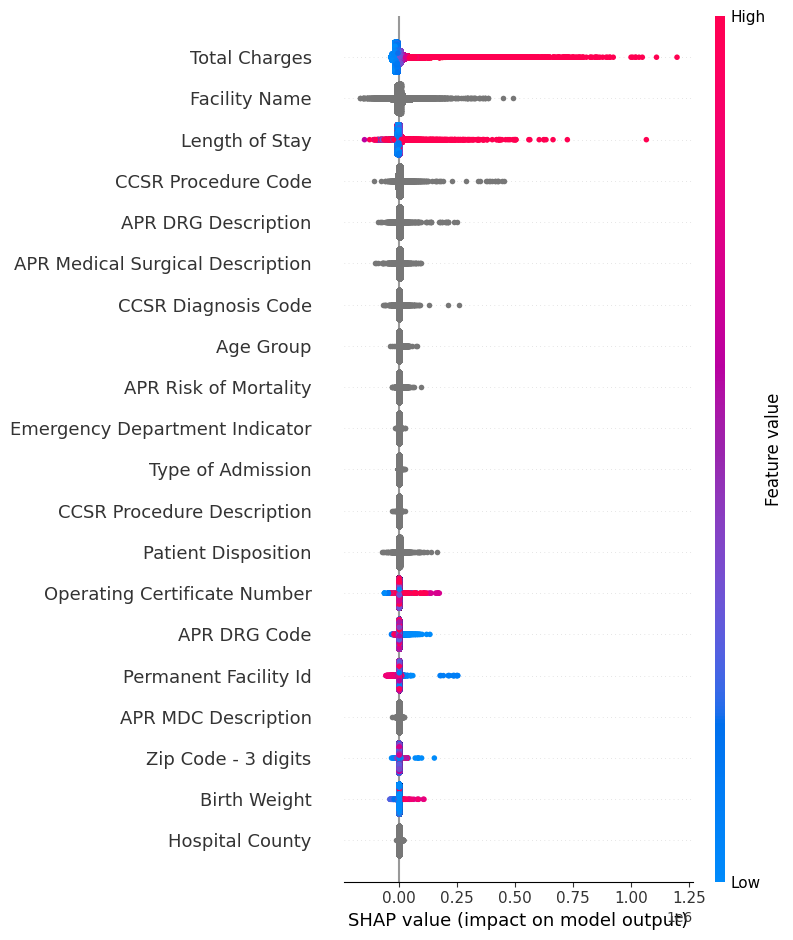

In [480]:
# Visualize feature importance
shap_values = explainer(X_test)
shap.summary_plot(shap_values, X_test)

In [481]:
sample_patient_dict = {
    "Hospital Service Area": "New York City",
    "Hospital County": "Kings",
    "Operating Certificate Number": 7001009,
    "Permanent Facility Id": 1294,
    "Facility Name": "Coney Island Hospital",
    "Age Group": "18 to 29",
    "Zip Code - 3 digits": 112,
    "Gender": "F",
    "Race": "Black/African American",
    "Ethnicity": "Not Span/Hispanic",
    "Length of Stay": 1,
    "Type of Admission": "Emergency",
    "Patient Disposition": "Home or Self Care",
    "Discharge Year": 2022,
    "CCSR Diagnosis Code": "INF012",
    "CCSR Diagnosis Description": "COVID-19",
    "CCSR Procedure Code": "ADM015",
    "CCSR Procedure Description": "ADMINISTRATION OF ANTIBIOTICS",
    "APR DRG Code": 137,
    "APR DRG Description": "MAJOR RESPIRATORY INFECTIONS AND INFLAMMATIONS",
    "APR MDC Code": 4,
    "APR MDC Description": "DISEASES AND DISORDERS OF THE RESPIRATORY SYSTEM",
    "APR Severity of Illness Code": 3,
    "APR Severity of Illness Description": "Major",
    "APR Risk of Mortality": "Moderate",
    "APR Medical Surgical Description": "Medical",
    "Payment Typology 1": "Medicaid",
    "Payment Typology 2": "Unknown",
    "Payment Typology 3": "Unknown",
    "Birth Weight": -1,
    "Emergency Department Indicator": "Y",
    "Total Charges": 8803.14
}
sample_patient_df = pd.DataFrame(sample_patient_dict, index=[0])


In [482]:
for col in data.select_dtypes(['category']).columns:
    sample_patient_df[col] = pd.Categorical(sample_patient_df[col], categories=data[col].cat.categories)

In [483]:
sample_patient_df

,Hospital Service Area,Hospital County,Operating Certificate Number,Permanent Facility Id,Facility Name,Age Group,Zip Code - 3 digits,Gender,Race,Ethnicity,...,APR Severity of Illness Code,APR Severity of Illness Description,APR Risk of Mortality,APR Medical Surgical Description,Payment Typology 1,Payment Typology 2,Payment Typology 3,Birth Weight,Emergency Department Indicator,Total Charges
0,New York City,Kings,7001009,1294,Coney Island Hospital,18 to 29,112,F,Black/African American,Not Span/Hispanic,...,NaN,Major,Moderate,Medical,Medicaid,Unknown,Unknown,-1,Y,8803.14


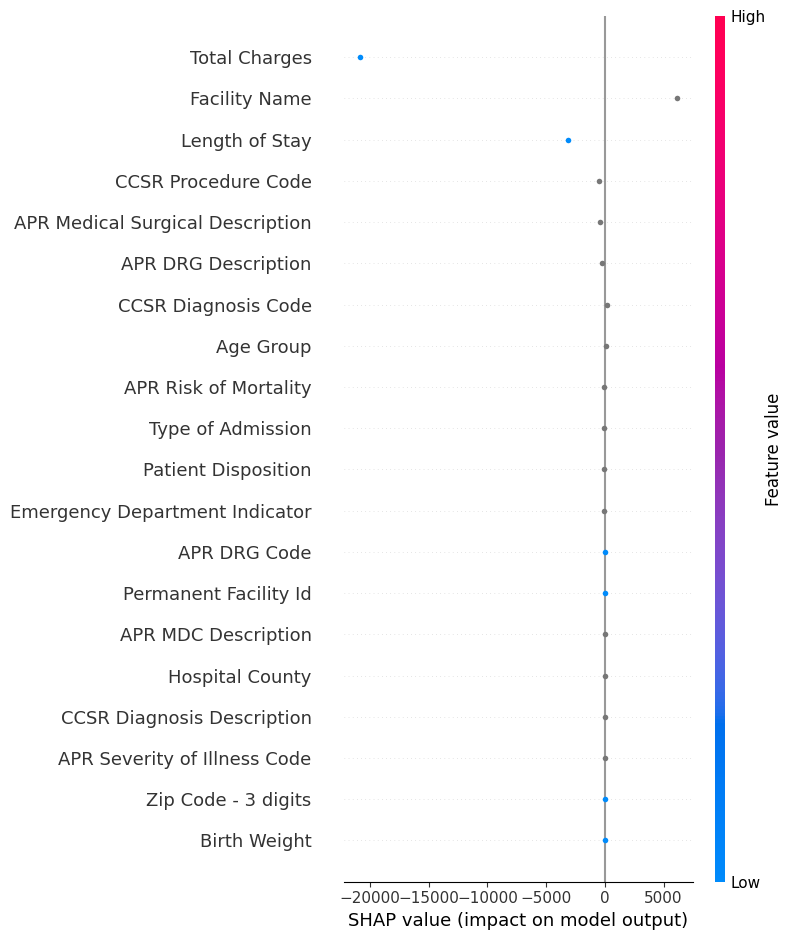

In [484]:
# shapley values for sample patient
shap_values = explainer(sample_patient_df)
shap.summary_plot(shap_values, sample_patient_df)

In [485]:
def get_patient_info(sample_patient_df):
    # shapley values for sample patient
    shap_values = explainer(sample_patient_df)
    info = dict()
    for i, col in enumerate(sample_patient_df.columns):
        info[col] = {
            "type": data_info[col]["type"],
            "value": shap_values.data[0][i],
            "shap value": shap_values.values[0][i].item(),
            "other options": data_info[col]["options"] if "options" in data_info[col] else []
        }
    return info

In [486]:
SYSTEM_PROMPT = '''
You are an expert in healthcare cost optimization and hospital operations strategy.

Your role is to analyze structured data from individual inpatient hospital cases. Each feature includes:
- The data type (e.g., int, float, str)
- The observed value for the case
- The SHAP value, which quantifies how much that feature contributed to the total inpatient cost
- A list of possible values the feature can take (if available)

Your goal is to:
1. Identify which features are the most significant cost drivers.
2. Propose feasible, actionable strategies to reduce their cost impact, based on the available options.
3. Ensure your recommendations do not compromise—ideally improve—the quality of care.

Respond only with specific, pragmatic suggestions tailored to the data provided.
'''

In [487]:
USER_PROMPT = f'''
You are given structured data for a single inpatient case.

Each feature contains:
- "type": the data type
- "value": the observed value
- "shap value": contribution to the total inpatient cost
- "other options": the possible values for that feature (if any)

Your tasks:
1. For each feature, suggest a specific, feasible strategy to reduce its cost impact, using the "other options" where applicable to that patient. If there is no strategy, leave this empty.
2. Conclude with a short summary (2–3 sentences) explaining the overall cost-reduction logic you applied.
3. Return your response in this JSON format only (no additional text):

{{
  "Feature Name 1": "strategy",
  "Feature Name 2": "strategy",
  ...
  "Summary": "your overall summary"
}}

Data:
###patient_info###
'''

In [488]:
patient_info = get_patient_info(sample_patient_df)

In [489]:
from langchain_community.chat_models import ChatOpenAI
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain.schema import HumanMessage, SystemMessage

# Choose a model available on OpenRouter (e.g., GPT-3.5, Mistral, Claude)
# llm = ChatOpenAI(
#     model="microsoft/phi-4-reasoning-plus:free",
#   # model="deepseek/deepseek-r1:free",
#     base_url="https://openrouter.ai/api/v1",
#     api_key="OR_API_KEY",
# )

# gemini google
llm = ChatGoogleGenerativeAI(
    model="gemini-2.0-flash",
    api_key="GEMINI_API_KEY",
)

# Send a test message
response = llm(
    [
        HumanMessage(
            content=USER_PROMPT.replace(
                "###patient_info###", json.dumps(patient_info)
            )
        ),
        SystemMessage(content=SYSTEM_PROMPT),
    ]
)

In [490]:
proposal = json.loads(response.content.strip("```json").strip("```").strip())

In [491]:
proposal

{'Hospital Service Area': "If feasible and clinically appropriate, consider transferring the patient to a hospital in a lower-cost service area within the network. For example, transferring to 'Capital/Adirondack' or 'Central NY'.",
 'Hospital County': 'If transfer is needed, consider Albany or another lower-cost county.',
 'Facility Name': '',
 'Age Group': '',
 'Zip Code - 3 digits': '',
 'Gender': '',
 'Race': '',
 'Ethnicity': '',
 'Length of Stay': 'Efforts should be made to safely discharge the patient as soon as medically appropriate to minimize the length of stay. Reducing LOS, if possible, will dramatically reduce costs.',
 'Type of Admission': "Since the admission was an Emergency, there's no option to change this. Focus on efficient treatment during the emergency admission.",
 'Patient Disposition': '',
 'Discharge Year': '',
 'CCSR Diagnosis Code': '',
 'CCSR Diagnosis Description': '',
 'CCSR Procedure Code': '',
 'CCSR Procedure Description': '',
 'APR DRG Code': '',
 'AP

In [492]:
model.predict(sample_patient_df).item()

4451.418289105391

In [497]:
min_cost = model.predict(sample_patient_df).item()
strategy = None
selected_option = None

for col, method in proposal.items():
    if col == "Summary":
        continue
    info = patient_info[col]
    print(col)
    if len(method) > 5:
        if info["type"] == "str":
            if "other options" in info:
                for option in info["other options"]:
                    updated_patient_dict = sample_patient_dict.copy()
                    # apply changes
                    updated_patient_dict[col] = option
                    updated_patient_df = pd.DataFrame(updated_patient_dict, index=[0])
                    for col in data.select_dtypes(['category']).columns:
                        updated_patient_df[col] = pd.Categorical(updated_patient_df[col], categories=data[col].cat.categories)
                    cost = model.predict(updated_patient_df)
                    print(col, option, cost)

                    if cost < min_cost:
                        min_cost = cost
                        strategy = col
                        selected_option = option
                        
        elif col == "Length of Stay":
            if "increas" in proposal[col].lower():
                for i in range(7, 22, 7):
                    updated_patient_dict = sample_patient_dict.copy()
                    # apply changes
                    updated_patient_dict[col] = i
                    updated_patient_df = pd.DataFrame(updated_patient_dict, index=[0])
                    for col in data.select_dtypes(['category']).columns:
                        updated_patient_df[col] = pd.Categorical(updated_patient_df[col], categories=data[col].cat.categories)
                    cost = model.predict(updated_patient_df)
                    print(col, i, cost)

                    if cost < min_cost:
                        min_cost = cost
                        strategy = col
                        selected_option = option

            if "decreas" in proposal[col].lower() or "reduc" in proposal[col].lower():
                for i in range(7, min(22, patient_info[col]["value"]), 7):
                    updated_patient_dict = sample_patient_dict.copy()
                    # apply changes
                    updated_patient_dict[col] = i
                    updated_patient_df = pd.DataFrame(updated_patient_dict, index=[0])
                    for col in data.select_dtypes(['category']).columns:
                        updated_patient_df[col] = pd.Categorical(updated_patient_df[col], categories=data[col].cat.categories)
                    cost = model.predict(updated_patient_df)
                    print(col, i, cost)

                    if cost < min_cost:
                        min_cost = cost
                        strategy = col
                        selected_option = option


Hospital Service Area
Emergency Department Indicator Capital/Adirondack [4451.41828911]
Emergency Department Indicator Central NY [4464.50831763]
Emergency Department Indicator Finger Lakes [4464.50831763]
Emergency Department Indicator Hudson Valley [4464.50831763]
Emergency Department Indicator Long Island [4464.50831763]
Emergency Department Indicator New York City [4464.50831763]
Emergency Department Indicator Southern Tier [4464.50831763]
Emergency Department Indicator Western NY [4464.50831763]
Hospital County
Emergency Department Indicator Albany [4451.41828911]
Emergency Department Indicator Allegany [4464.50831763]
Emergency Department Indicator Bronx [4464.50831763]
Emergency Department Indicator Broome [4464.50831763]
Emergency Department Indicator Cattaraugus [4464.50831763]
Emergency Department Indicator Cayuga [4464.50831763]
Emergency Department Indicator Chautauqua [4464.50831763]
Emergency Department Indicator Chemung [4464.50831763]
Emergency Department Indicator Chen

In [498]:
strategy, selected_option

(None, None)